# **Day 48: Gaussian Mixture Models and the EM Algorithm**
*Module 8 - Unsupervised Learning*

A **Gaussian Mixture Model (GMM)** says the data come from $K$ Gaussian "sources". Unlike K-Means it gives **soft** (probabilistic) memberships, **elliptical** clusters of different sizes, and a full **density model** we can sample from and use for anomaly detection. It is fitted with the **Expectation-Maximisation (EM)** algorithm, one of the most important algorithms in statistics.

> A Gaussian mixture model describes data as a mix of several bell-shaped groups and gives each point a probability of belonging to each group (soft clustering). The EM algorithm fits it by alternating guessing and updating.
>
> *Example:* A mixed pixel can belong 60% to cropland and 40% to shrub instead of being forced into one class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
rng = np.random.default_rng(48)

def draw_ellipses(ax, means, covs, color="k"):
    for m, C in zip(means, covs):
        vals, vecs = np.linalg.eigh(C); ang = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
        for nsig in [1, 2]:
            ax.add_patch(Ellipse(m, 2 * nsig * np.sqrt(vals[1]), 2 * nsig * np.sqrt(vals[0]), angle=ang, fill=False, color=color, lw=1.2, alpha=0.8))

## **1. Data From Three Elliptical Sources**

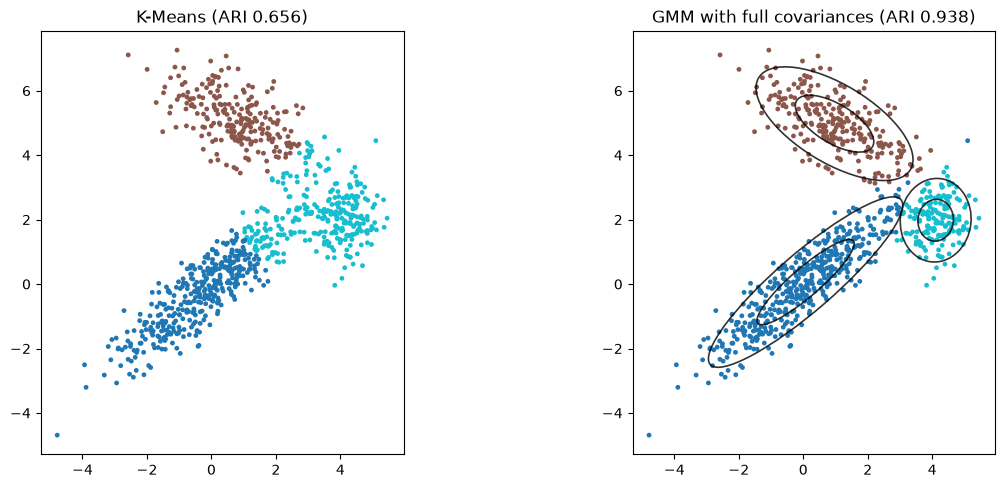

In [2]:
true_means = np.array([[0, 0], [4, 2], [1, 5]])
true_covs = np.array([[[2.0, 1.5], [1.5, 1.5]], [[0.4, 0], [0, 0.4]], [[1.5, -0.8], [-0.8, 1.0]]])
true_w = [0.5, 0.2, 0.3]
z = rng.choice(3, 900, p=true_w)
X = np.array([rng.multivariate_normal(true_means[k], true_covs[k]) for k in z])
km_lab = KMeans(3, n_init=10, random_state=0).fit_predict(X)
gmm = GaussianMixture(3, covariance_type="full", random_state=0).fit(X)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(*X.T, c=km_lab, s=6, cmap="tab10"); axes[0].set_title(f"K-Means (ARI {adjusted_rand_score(z, km_lab):.3f})")
axes[1].scatter(*X.T, c=gmm.predict(X), s=6, cmap="tab10"); draw_ellipses(axes[1], gmm.means_, gmm.covariances_)
axes[1].set_title(f"GMM with full covariances (ARI {adjusted_rand_score(z, gmm.predict(X)):.3f})")
for ax in axes: ax.set_aspect("equal")
plt.show()

## **2. EM From Scratch**
We do not know which source generated each point (latent variable $z_i$). EM alternates:
- **E-step**: responsibilities $\gamma_{ik} = P(z_i = k\mid\mathbf x_i) = \frac{\pi_k\mathcal N(\mathbf x_i;\boldsymbol\mu_k,\Sigma_k)}{\sum_j\pi_j\mathcal N(\mathbf x_i;\boldsymbol\mu_j,\Sigma_j)}$
- **M-step**: weighted MLE with $N_k = \sum_i\gamma_{ik}$: $\pi_k = N_k/n$, $\boldsymbol\mu_k = \frac{1}{N_k}\sum_i\gamma_{ik}\mathbf x_i$, $\Sigma_k = \frac{1}{N_k}\sum_i\gamma_{ik}(\mathbf x_i-\boldsymbol\mu_k)(\mathbf x_i-\boldsymbol\mu_k)^\top$

Each iteration increases (never decreases) the log-likelihood $\sum_i\log\sum_k\pi_k\mathcal N(\mathbf x_i;\cdot)$.

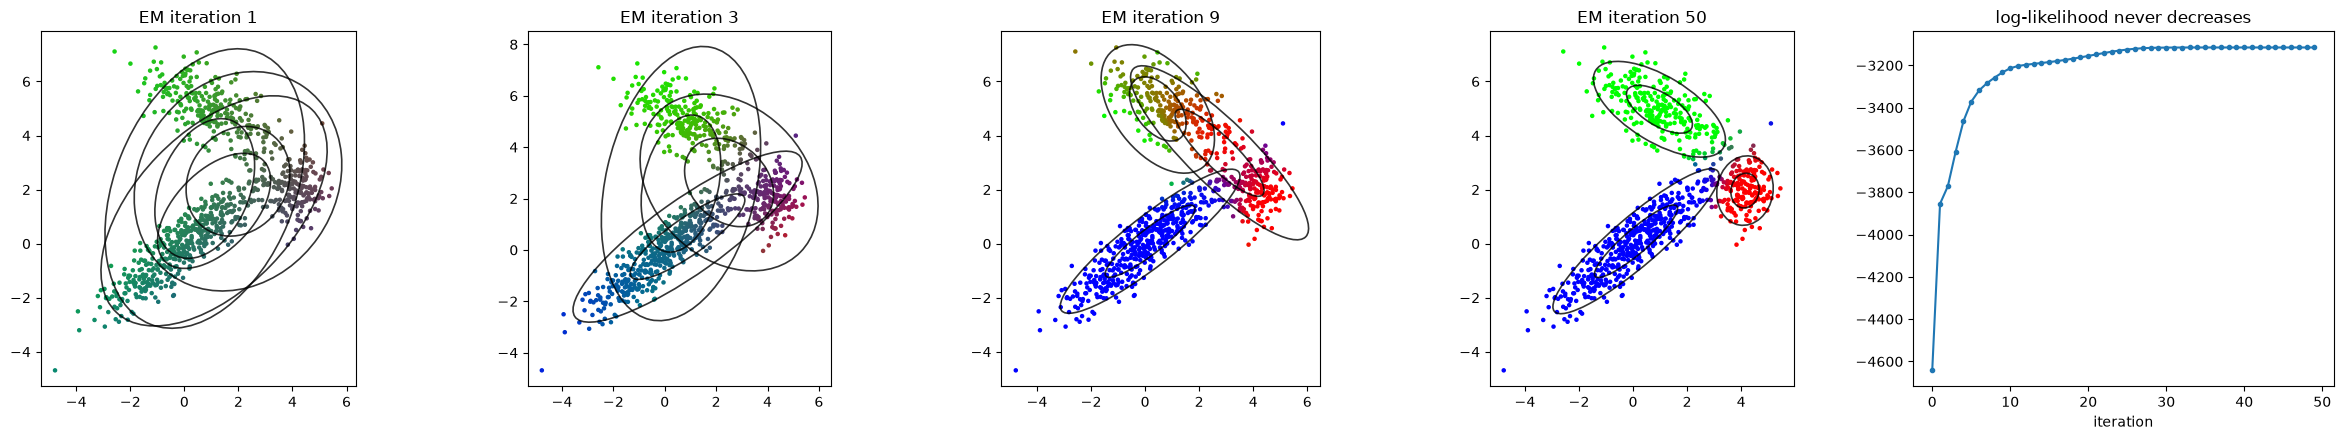

scratch weights: [0.189 0.286 0.525] | sklearn: [0.196 0.285 0.518] | true: [0.2, 0.3, 0.5]


In [3]:
def em_gmm(X, K, n_iter=100, seed=0, tol=1e-6):
    r = np.random.default_rng(seed); n, d = X.shape
    mu = X[r.choice(n, K, replace=False)]; Sigma = np.array([np.cov(X.T) for _ in range(K)]); pi = np.full(K, 1 / K)
    ll_hist, snapshots = [], []
    for it in range(n_iter):
        dens = np.column_stack([pi[k] * multivariate_normal(mu[k], Sigma[k]).pdf(X) for k in range(K)])     # E-step
        ll = np.log(dens.sum(1)).sum(); ll_hist.append(ll)
        gamma = dens / dens.sum(1, keepdims=True)
        Nk = gamma.sum(0)                                                                                     # M-step
        pi = Nk / n
        mu = (gamma.T @ X) / Nk[:, None]
        Sigma = np.array([((gamma[:, k, None] * (X - mu[k])).T @ (X - mu[k])) / Nk[k] + 1e-6 * np.eye(d) for k in range(K)])
        snapshots.append((mu.copy(), Sigma.copy(), gamma.copy()))
        if it > 0 and ll_hist[-1] - ll_hist[-2] < tol:
            break
    return pi, mu, Sigma, gamma, ll_hist, snapshots

pi, mu, Sigma, gamma, ll_hist, snaps = em_gmm(X, 3, seed=2)
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
for ax, it in zip(axes[:4], [0, 2, 8, len(snaps) - 1]):
    m_, S_, g_ = snaps[it]
    ax.scatter(*X.T, c=g_, s=5); draw_ellipses(ax, m_, S_); ax.set_title(f"EM iteration {it + 1}"); ax.set_aspect("equal")
axes[4].plot(ll_hist, "o-", ms=3); axes[4].set(title="log-likelihood never decreases", xlabel="iteration")
plt.tight_layout(); plt.show()
print("scratch weights:", np.sort(pi).round(3), "| sklearn:", np.sort(gmm.weights_).round(3), "| true:", sorted(true_w))

Point colours are the soft responsibilities (shown as RGB). Points between clusters have mixed colours: **uncertainty in membership**, which K-Means cannot express.

## **3. Covariance Types**

| `covariance_type` | Each component has | Parameters per component (d dims) |
|---|---|---|
| `full` | its own general covariance | $d(d+1)/2$ |
| `tied` | one shared general covariance | shared |
| `diag` | own axis-aligned ellipse | $d$ |
| `spherical` | own circle | 1 |

## **4. Choosing K and the Covariance Type With BIC**
$\text{BIC} = -2\log\hat{\mathcal L} + p\log n$ penalises the number of parameters $p$. Lower is better.

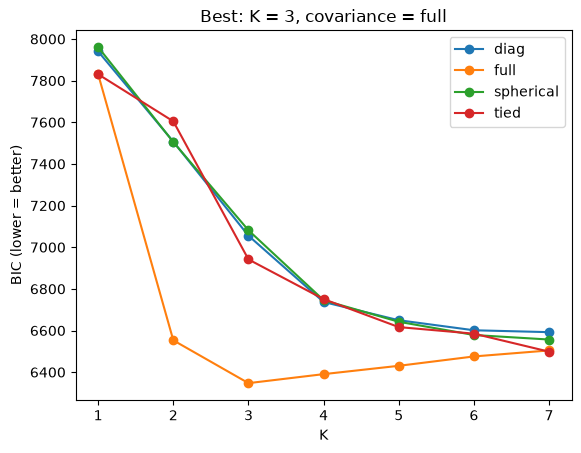

In [4]:
rows = []
for cov in ["spherical", "diag", "tied", "full"]:
    for k in range(1, 8):
        g = GaussianMixture(k, covariance_type=cov, random_state=0, n_init=3).fit(X)
        rows.append({"cov": cov, "K": k, "BIC": g.bic(X), "AIC": g.aic(X)})
bic = pd.DataFrame(rows)
for cov, grp in bic.groupby("cov"):
    plt.plot(grp.K, grp.BIC, "o-", label=cov)
best = bic.loc[bic.BIC.idxmin()]
plt.xlabel("K"); plt.ylabel("BIC (lower = better)"); plt.legend(); plt.title(f"Best: K = {best.K}, covariance = {best['cov']}"); plt.show()

## **5. Density Estimation, Sampling and Anomaly Detection**
A fitted GMM is a full probability density. Low-density points are anomalies; new synthetic samples can be generated.

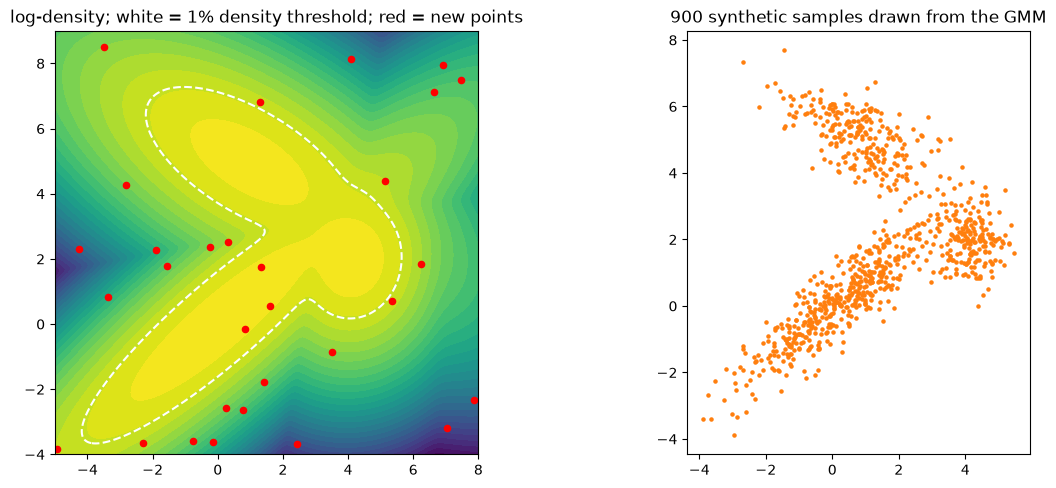

anomalies flagged among the 30 random points: 27


In [5]:
xx, yy = np.meshgrid(np.linspace(-5, 8, 300), np.linspace(-4, 9, 300))
logdens = gmm.score_samples(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
outliers = rng.uniform([-5, -4], [8, 9], (30, 2))
scores = gmm.score_samples(np.vstack([X, outliers]))
thr = np.percentile(gmm.score_samples(X), 1)                              # flag the lowest 1% density as anomalies
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].contourf(xx, yy, logdens, levels=30, cmap="viridis"); axes[0].scatter(*outliers.T, c="r", s=20)
axes[0].contour(xx, yy, logdens, levels=[thr], colors="w"); axes[0].set_title("log-density; white = 1% density threshold; red = new points")
samples, _ = gmm.sample(900)
axes[1].scatter(*samples.T, s=5, c="C1"); axes[1].set_title("900 synthetic samples drawn from the GMM")
for ax in axes: ax.set_aspect("equal")
plt.show()
print(f"anomalies flagged among the 30 random points: {np.sum(gmm.score_samples(outliers) < thr)}")

# **Part 2: Going Deeper**

### K-Means is a special case of EM
With spherical covariances $\sigma^2 I$ shared by all components and $\sigma\to 0$, responsibilities become **hard** 0/1 assignments to the nearest mean, and the M-step becomes the mean update: exactly Lloyd's algorithm. K-Means = "hard EM" for an isotropic GMM.

In [6]:
def soft_kmeans_resp(X, means, sigma):
    d2 = ((X[:, None] - means[None]) ** 2).sum(-1); logits = -d2 / (2 * sigma ** 2)
    logits -= logits.max(1, keepdims=True); R = np.exp(logits); return R / R.sum(1, keepdims=True)
for s in [3.0, 1.0, 0.3, 0.05]:
    R = soft_kmeans_resp(X, gmm.means_, s)
    print(f"sigma = {s:<4}: mean max responsibility = {R.max(1).mean():.3f}  (1.0 = hard K-Means assignments)")

sigma = 3.0 : mean max responsibility = 0.619  (1.0 = hard K-Means assignments)
sigma = 1.0 : mean max responsibility = 0.969  (1.0 = hard K-Means assignments)
sigma = 0.3 : mean max responsibility = 0.997  (1.0 = hard K-Means assignments)
sigma = 0.05: mean max responsibility = 1.000  (1.0 = hard K-Means assignments)


### Bayesian GMM: let the data choose K
A Dirichlet-process prior on the weights pushes unnecessary components towards zero weight. Give it a generous maximum K and inspect the weights.

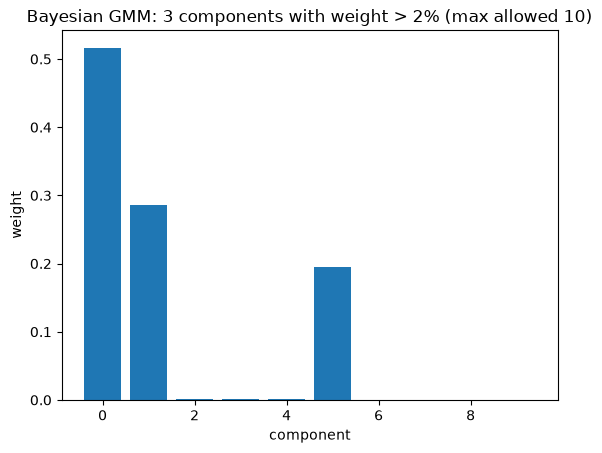

In [7]:
bgmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type="dirichlet_process", weight_concentration_prior=0.01,
                               max_iter=1000, random_state=0).fit(X)
plt.bar(range(10), bgmm.weights_); plt.xlabel("component"); plt.ylabel("weight")
plt.title(f"Bayesian GMM: {np.sum(bgmm.weights_ > 0.02)} components with weight > 2% (max allowed 10)"); plt.show()

## **Practice Problems**
1. Fit GMMs with `covariance_type="diag"` and `"spherical"` (K = 3). How do the ellipses and ARI change?
2. Run `em_gmm` from 10 random seeds. Do all reach the same log-likelihood? (EM finds local maxima.)
3. Use a GMM as a **classifier**: fit one GMM (K = 2) per class of `load_breast_cancer` (after PCA to 5 dimensions) and classify by the highest class-conditional likelihood x prior.
4. *(Advanced)* Modify `em_gmm` to use a **tied** covariance (one shared $\Sigma$). Derive and implement the M-step.

In [8]:
# Solution 1
for cov in ["diag", "spherical"]:
    g = GaussianMixture(3, covariance_type=cov, random_state=0).fit(X); print(cov, "ARI", round(adjusted_rand_score(z, g.predict(X)), 3))
# Solution 2
print("final log-likelihoods:", sorted(round(float(em_gmm(X, 3, seed=s)[4][-1]), 1) for s in range(10)))
# Solution 3
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, stratify=yb, random_state=0)
sc = StandardScaler().fit(Xb_tr); pca = PCA(5).fit(sc.transform(Xb_tr))
Z_tr, Z_te = pca.transform(sc.transform(Xb_tr)), pca.transform(sc.transform(Xb_te))
class_gmms = [GaussianMixture(2, random_state=0).fit(Z_tr[yb_tr == c]) for c in [0, 1]]
logp = np.column_stack([g.score_samples(Z_te) + np.log(np.mean(yb_tr == c)) for c, g in enumerate(class_gmms)])
print("GMM classifier accuracy:", round(np.mean(logp.argmax(1) == yb_te), 3))
# Solution 4: tied M-step: Sigma = (1/n) sum_k sum_i gamma_ik (x_i - mu_k)(x_i - mu_k)^T
def tied_sigma(X, gamma, mu):
    return sum(((gamma[:, k, None] * (X - mu[k])).T @ (X - mu[k])) for k in range(len(mu))) / len(X)
print("tied covariance from the scratch EM responsibilities:\n", tied_sigma(X, gamma, mu).round(3))

diag ARI 0.674
spherical ARI 0.681


final log-likelihoods: [-3115.4, -3115.4, -3115.4, -3115.4, -3115.4, -3115.4, -3115.4, -3115.4, -3115.4, -3115.4]
GMM classifier accuracy: 0.937
tied covariance from the scratch EM responsibilities:
 [[1.718 0.786]
 [0.786 1.245]]


## **Key References**
- Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm. *Journal of the Royal Statistical Society B*, 39(1), 1-38.
- McLachlan, G. J., & Peel, D. (2000). *Finite Mixture Models*. Wiley.
- Schwarz, G. (1978). Estimating the dimension of a model. *The Annals of Statistics*, 6(2), 461-464 (BIC).
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapter 9. Springer.
- Blei, D. M., & Jordan, M. I. (2006). Variational inference for Dirichlet process mixtures. *Bayesian Analysis*, 1(1), 121-143.